# V2 Advanced Bandit Evaluation: Linear Thompson Sampling and LASSO LinUCB

This notebook evaluates the next two contextual bandit upgrades on the V2 warfarin feature sets:

1. **Linear Thompson Sampling** — contextual Bayesian-style exploration using one linear reward model per dose arm.
2. **LASSO LinUCB** — sparse per-arm LASSO models with an optional UCB bonus over the selected active feature set.

The notebook intentionally reuses the V2 modeling table and feature-set manifest generated by `src/preprocessing/preprocess_v2.ipynb`. It does not regenerate preprocessing and does not modify earlier notebooks.


In [3]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / 'src').exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.bandits.linear_thompson_sampling import LinearThompsonSampling
from src.bandits.lasso_bandit import LassoLinUCB
from src.evaluation.advanced_bandit_benchmark import (
    DEFAULT_LASSO_GRID,
    DEFAULT_TS_GRID,
    combine_advanced_results,
    evaluate_lasso_grid,
    evaluate_linear_ts_grid,
    load_top_feature_sets_from_ridge_results,
    make_static_baselines_for_feature_sets,
    plot_advanced_leaderboard,
    save_advanced_benchmark,
)
from src.evaluation.bandit_evaluation import plot_learning_curves
from src.evaluation.feature_set_benchmark import load_v2_assets, list_feature_sets

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 120)

RESULT_DIR = REPO_ROOT / 'results' / 'v2_advanced_bandits'
RESULT_DIR.mkdir(parents=True, exist_ok=True)


## Load V2 modeling assets and choose feature sets

By default we evaluate the top feature sets discovered in the previous RidgeLinUCB notebook. This keeps the LASSO runs manageable while still focusing on the most promising feature representations. Set `USE_ALL_FEATURE_SETS = True` if you want to run every V2 feature set.

In [4]:
df, feature_sets, v2_output_dir = load_v2_assets(REPO_ROOT)
feature_set_summary = list_feature_sets(feature_sets)
feature_set_summary


,feature_set,n_features
0,v2_expanded_regression_hw_with_indication_target_inr,235
1,v2_pharmacogenetic_augmented_regression_hw,217
2,v2_strict_group_median_hw_full_dummies,213
3,v2_strict_knn_hw_full_dummies,213
4,v2_strict_regression_hw_full_dummies,213
5,v2_strict_regression_hw_drop_first,165
6,v2_iwpc_minimal_regression_hw,26


In [5]:
USE_ALL_FEATURE_SETS = False
TOP_N_FEATURE_SETS = 3
RIDGE_LEADERBOARD = REPO_ROOT / 'results' / 'v2_feature_set_evaluation' / 'combined_feature_set_leaderboard.csv'

if USE_ALL_FEATURE_SETS:
    selected_feature_sets = feature_set_summary['feature_set'].tolist()
else:
    selected_feature_sets = load_top_feature_sets_from_ridge_results(
        RIDGE_LEADERBOARD,
        top_n=TOP_N_FEATURE_SETS,
    )

selected_feature_sets


['v2_pharmacogenetic_augmented_regression_hw',
 'v2_strict_regression_hw_full_dummies',
 'v2_strict_knn_hw_full_dummies']

In [6]:
static_baselines = make_static_baselines_for_feature_sets(df, selected_feature_sets)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])


,feature_set,algorithm,accuracy,fraction_incorrect,n_correct,n_total
2,v2_pharmacogenetic_augmented_regression_hw,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,3820,5528
1,v2_pharmacogenetic_augmented_regression_hw,Clinical Formula (regression_hw),0.639110,0.360890,3533,5528
0,v2_pharmacogenetic_augmented_regression_hw,Fixed Medium Dose,0.611795,0.388205,3382,5528
8,v2_strict_knn_hw_full_dummies,Pharmacogenetic Formula (knn_hw),0.690123,0.309877,3815,5528
7,v2_strict_knn_hw_full_dummies,Clinical Formula (knn_hw),0.640738,0.359262,3542,5528
6,v2_strict_knn_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,3382,5528
5,v2_strict_regression_hw_full_dummies,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,3820,5528
4,v2_strict_regression_hw_full_dummies,Clinical Formula (regression_hw),0.639110,0.360890,3533,5528
3,v2_strict_regression_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,3382,5528


## Hyperparameter grids

These grids are intentionally compact. They are designed to answer the first important question: whether LinearTS or LASSO LinUCB beats the tuned RidgeLinUCB region around 68%. After this screen, widen the grid only around the best few configurations.

For LinearTS:

- `lambda_reg` controls ridge/posterior shrinkage.
- `sample_scale` controls posterior sampling/exploration strength.
- `covariance_type='diagonal'` is the default because full covariance sampling is much slower for repeated simulations.

For LASSO LinUCB:

- `lasso_alpha` controls sparsity.
- `ucb_alpha` controls the UCB bonus after sparse model fitting.
- `min_samples_per_arm` forces early exploration so every arm has enough samples for LASSO fitting.
- `refit_frequency` controls how often per-arm LASSO models are refit.


In [7]:
TS_GRID = DEFAULT_TS_GRID
LASSO_GRID = DEFAULT_LASSO_GRID
SCREEN_SEEDS = range(3)

print('LinearTS grid:')
for row in TS_GRID:
    print(row)

print('LassoLinUCB grid:')
for row in LASSO_GRID:
    print(row)


LinearTS grid:
{'lambda_reg': 5.0, 'sample_scale': 0.01, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.01, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.025, 'covariance_type': 'diagonal'}
{'lambda_reg': 20.0, 'sample_scale': 0.025, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.05, 'covariance_type': 'diagonal'}
LassoLinUCB grid:
{'lasso_alpha': 0.0005, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 15, 'refit_frequency': 50}
{'lasso_alpha': 0.001, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 15, 'refit_frequency': 50}
{'lasso_alpha': 0.0025, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 20, 'refit_frequency': 50}
{'lasso_alpha': 0.001, 'ucb_alpha': 0.025, 'lambda_reg': 10.0, 'min_samples_per_arm': 20, 'refit_frequency': 50}
{'lasso_alpha': 0.0025, 'ucb_alpha': 0.025, 'lambda_reg': 10.0, 'min_samples_per_arm': 20, 'refit_frequency': 50}


## Linear Thompson Sampling screen

In [8]:
ts_summary, ts_results, ts_scale_stats = evaluate_linear_ts_grid(
    df=df,
    feature_sets=feature_sets,
    bandit_cls=LinearThompsonSampling,
    feature_set_names=selected_feature_sets,
    param_grid=TS_GRID,
    seeds=SCREEN_SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

ts_written = save_advanced_benchmark(
    output_dir=RESULT_DIR / 'linear_ts_screen',
    prefix='linear_ts_screen',
    summary=ts_summary,
    results=ts_results,
    scale_stats=ts_scale_stats,
)

ts_summary.head(15)


LinearTS feature set: v2_pharmacogenetic_augmented_regression_hw (217 features)
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
  LinearTS(lambda=10, scale=0.05, cov=diagonal)
LinearTS feature set: v2_strict_regression_hw_full_dummies (213 features)
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
  LinearTS(lambda=10, scale=0.05, cov=diagonal)
LinearTS feature set: v2_strict_knn_hw_full_dummies (213 features)
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
  LinearTS(lambda=10, scale=0.05, cov=diagonal)


,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type
1,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",3,0.676978,0.001382,1785.666667,7.637626,0.323022,0.001382,0.693333,0.034429,0.001563,8.642788,0.001563,0.038960,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal
2,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",3,0.676556,0.003658,1788.000000,20.223748,0.323444,0.003658,0.695333,0.034312,0.004140,22.885326,0.004140,0.038828,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal
0,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",3,0.674747,0.003531,1798.000000,19.519221,0.325253,0.003531,0.694000,0.033645,0.003996,22.088078,0.003996,0.038073,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal
4,"LinearTS(lambda=10, scale=0.05, cov=diagonal)",3,0.673722,0.004166,1803.666667,23.028967,0.326278,0.004166,0.689333,0.039107,0.004714,26.059730,0.004714,0.044253,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.05, cov=diagonal)",217,10.0,0.050,diagonal
5,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",3,0.666305,0.000209,1844.666667,1.154701,0.333695,0.000209,0.682667,0.024685,0.000236,1.306667,0.000236,0.027933,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",213,5.0,0.010,diagonal
3,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",3,0.666184,0.012050,1845.333333,66.613312,0.333816,0.012050,0.686000,0.040000,0.013636,75.380059,0.013636,0.045264,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",217,20.0,0.025,diagonal
6,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",3,0.665099,0.002567,1851.333333,14.189198,0.334901,0.002567,0.684000,0.022271,0.002905,16.056589,0.002905,0.025202,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",213,10.0,0.010,diagonal
10,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",3,0.664677,0.003592,1853.666667,19.857828,0.335323,0.003592,0.692667,0.024685,0.004065,22.471248,0.004065,0.027933,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",213,5.0,0.010,diagonal
12,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",3,0.661300,0.005724,1872.333333,31.643851,0.338700,0.005724,0.686667,0.033247,0.006478,35.808389,0.006478,0.037622,v2_strict_knn_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",213,10.0,0.025,diagonal
9,"LinearTS(lambda=10, scale=0.05, cov=diagonal)",3,0.661240,0.001462,1872.666667,8.082904,0.338760,0.001462,0.672667,0.032021,0.001655,9.146667,0.001655,0.036235,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.05, cov=diagonal)",213,10.0,0.050,diagonal


## LASSO LinUCB screen

This will be slower than LinearTS because the sparse models are refit online. The default grid keeps the first pass compact. If a configuration looks promising, run a narrower second grid around its `lasso_alpha`, `ucb_alpha`, and warmup settings.

In [9]:
lasso_summary, lasso_results, lasso_scale_stats = evaluate_lasso_grid(
    df=df,
    feature_sets=feature_sets,
    bandit_cls=LassoLinUCB,
    feature_set_names=selected_feature_sets,
    param_grid=LASSO_GRID,
    seeds=SCREEN_SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

lasso_written = save_advanced_benchmark(
    output_dir=RESULT_DIR / 'lasso_linucb_screen',
    prefix='lasso_linucb_screen',
    summary=lasso_summary,
    results=lasso_results,
    scale_stats=lasso_scale_stats,
)

lasso_summary.head(15)


LassoLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features)
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_strict_regression_hw_full_dummies (213 features)
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_strict_knn_hw_full_dummies (213 features)
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)

,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
2,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",3,0.668174,0.004708,1834.333333,26.025628,0.331826,0.004708,0.684000,0.020298,0.005328,29.450771,0.005328,0.022969,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",217,10.0,0.0025,0.000,20,50
4,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",3,0.668114,0.003145,1834.666667,17.387735,0.331886,0.003145,0.686667,0.028095,0.003559,19.676075,0.003559,0.031793,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",217,10.0,0.0025,0.025,20,50
3,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)",3,0.667451,0.004244,1838.333333,23.459184,0.332549,0.004244,0.690667,0.022030,0.004802,26.546566,0.004802,0.024930,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)",217,10.0,0.0010,0.025,20,50
1,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)",3,0.663953,0.002721,1857.666667,15.044379,0.336047,0.002721,0.692000,0.025534,0.003080,17.024317,0.003080,0.028895,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)",217,10.0,0.0010,0.000,15,50
12,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",3,0.663290,0.000910,1861.333333,5.033223,0.336710,0.000910,0.680667,0.025794,0.001030,5.695628,0.001030,0.029189,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",213,10.0,0.0025,0.000,20,50
0,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)",3,0.663109,0.001060,1862.333333,5.859465,0.336891,0.001060,0.692000,0.034176,0.001199,6.630609,0.001199,0.038674,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)",217,10.0,0.0005,0.000,15,50
7,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",3,0.663049,0.002233,1862.666667,12.342339,0.336951,0.002233,0.684667,0.019218,0.002527,13.966671,0.002527,0.021747,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",213,10.0,0.0025,0.000,20,50
13,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)",3,0.662446,0.003301,1866.000000,18.248288,0.337554,0.003301,0.694667,0.024028,0.003736,20.649881,0.003736,0.027190,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)",213,10.0,0.0010,0.025,20,50
14,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",3,0.662325,0.003424,1866.666667,18.929694,0.337675,0.003424,0.687333,0.028589,0.003875,21.420966,0.003875,0.032352,v2_strict_knn_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",213,10.0,0.0025,0.025,20,50
9,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",3,0.660878,0.003176,1874.666667,17.559423,0.339122,0.003176,0.683333,0.017243,0.003594,19.870358,0.003594,0.019513,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",213,10.0,0.0025,0.025,20,50


## Combined leaderboard

In [10]:
advanced_summary = pd.concat([ts_summary, lasso_summary], ignore_index=True).sort_values(
    'final_accuracy_mean', ascending=False
)
advanced_results = combine_advanced_results(ts_results, lasso_results)

advanced_summary.to_csv(RESULT_DIR / 'advanced_bandit_summary.csv', index=False)
advanced_results.to_csv(RESULT_DIR / 'advanced_bandit_step_results.csv', index=False)
static_baselines.to_csv(RESULT_DIR / 'static_baselines_for_selected_feature_sets.csv', index=False)

advanced_summary.head(25)


,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",3,0.676978,0.001382,1785.666667,7.637626,0.323022,0.001382,0.693333,0.034429,0.001563,8.642788,0.001563,0.038960,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal,NaN,NaN,NaN,NaN
1,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",3,0.676556,0.003658,1788.000000,20.223748,0.323444,0.003658,0.695333,0.034312,0.004140,22.885326,0.004140,0.038828,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal,NaN,NaN,NaN,NaN
2,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",3,0.674747,0.003531,1798.000000,19.519221,0.325253,0.003531,0.694000,0.033645,0.003996,22.088078,0.003996,0.038073,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal,NaN,NaN,NaN,NaN
3,"LinearTS(lambda=10, scale=0.05, cov=diagonal)",3,0.673722,0.004166,1803.666667,23.028967,0.326278,0.004166,0.689333,0.039107,0.004714,26.059730,0.004714,0.044253,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.05, cov=diagonal)",217,10.0,0.050,diagonal,NaN,NaN,NaN,NaN
15,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",3,0.668174,0.004708,1834.333333,26.025628,0.331826,0.004708,0.684000,0.020298,0.005328,29.450771,0.005328,0.022969,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",217,10.0,NaN,NaN,0.0025,0.000,20.0,50.0
16,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",3,0.668114,0.003145,1834.666667,17.387735,0.331886,0.003145,0.686667,0.028095,0.003559,19.676075,0.003559,0.031793,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0.025, lambda=10, warmup=20, refit=50)",217,10.0,NaN,NaN,0.0025,0.025,20.0,50.0
17,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)",3,0.667451,0.004244,1838.333333,23.459184,0.332549,0.004244,0.690667,0.022030,0.004802,26.546566,0.004802,0.024930,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)",217,10.0,NaN,NaN,0.0010,0.025,20.0,50.0
4,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",3,0.666305,0.000209,1844.666667,1.154701,0.333695,0.000209,0.682667,0.024685,0.000236,1.306667,0.000236,0.027933,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",213,5.0,0.010,diagonal,NaN,NaN,NaN,NaN
5,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",3,0.666184,0.012050,1845.333333,66.613312,0.333816,0.012050,0.686000,0.040000,0.013636,75.380059,0.013636,0.045264,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=20, scale=0.025, cov=diagonal)",217,20.0,0.025,diagonal,NaN,NaN,NaN,NaN
6,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",3,0.665099,0.002567,1851.333333,14.189198,0.334901,0.002567,0.684000,0.022271,0.002905,16.056589,0.002905,0.025202,v2_strict_regression_hw_full_dummies,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",213,10.0,0.010,diagonal,NaN,NaN,NaN,NaN


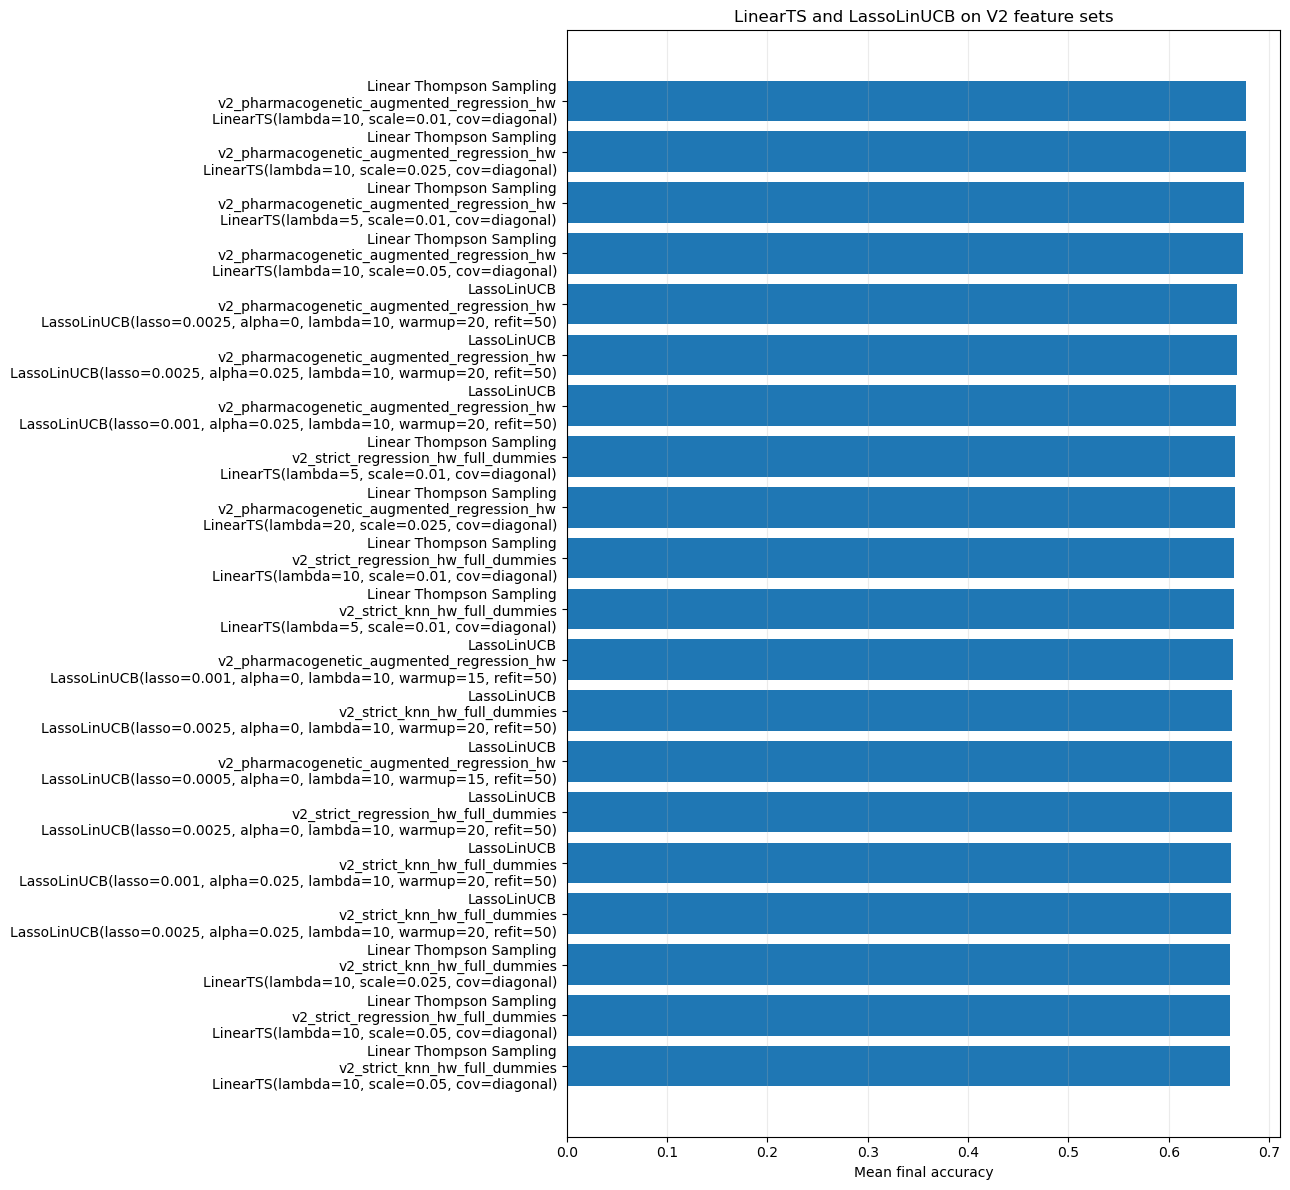

In [11]:
fig, ax = plot_advanced_leaderboard(
    advanced_summary,
    top_n=20,
    title='LinearTS and LassoLinUCB on V2 feature sets',
)
fig.savefig(RESULT_DIR / 'advanced_bandit_leaderboard.png', dpi=180, bbox_inches='tight')
plt.show()


## Learning curves for the best configurations

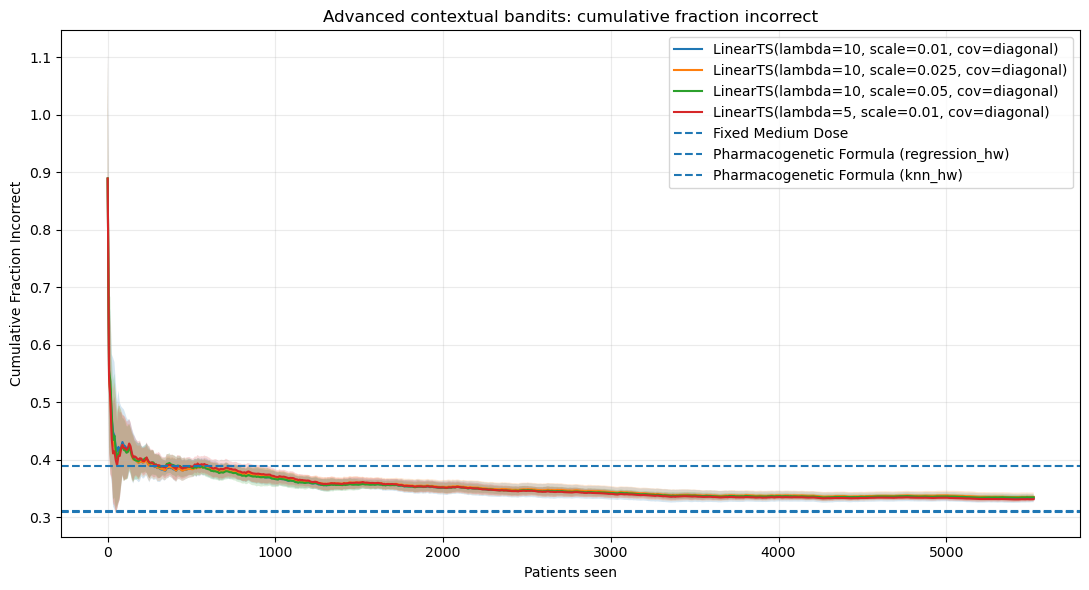

In [12]:
top_algorithms = advanced_summary.head(4)['algorithm'].tolist()
top_results = advanced_results[advanced_results['algorithm'].isin(top_algorithms)].copy()

baseline_error_rates = {
    row['algorithm']: 1.0 - row['accuracy']
    for _, row in static_baselines.iterrows()
    if 'Pharmacogenetic' in row['algorithm'] or row['algorithm'] == 'Fixed Medium Dose'
}

fig, ax = plot_learning_curves(
    top_results,
    metric='cumulative_fraction_incorrect',
    baseline_rates=baseline_error_rates,
    title='Advanced contextual bandits: cumulative fraction incorrect',
)
fig.savefig(RESULT_DIR / 'advanced_bandit_learning_curves.png', dpi=180, bbox_inches='tight')
plt.show()


## Optional: focused rerun of the top configurations with more seeds

Set `RUN_FOCUSED_RERUN = True` after the first screen. This reruns only the best LinearTS and best LASSO configurations with more seeds for a more stable final estimate.

In [13]:
RUN_FOCUSED_RERUN = True
FOCUSED_SEEDS = range(10)

if RUN_FOCUSED_RERUN:
    best_ts = ts_summary.sort_values('final_accuracy_mean', ascending=False).iloc[0]
    best_lasso = lasso_summary.sort_values('final_accuracy_mean', ascending=False).iloc[0]

    focused_ts_grid = [{
        'lambda_reg': float(best_ts['lambda_reg']),
        'sample_scale': float(best_ts['sample_scale']),
        'covariance_type': best_ts['covariance_type'],
    }]
    focused_lasso_grid = [{
        'lasso_alpha': float(best_lasso['lasso_alpha']),
        'ucb_alpha': float(best_lasso['ucb_alpha']),
        'lambda_reg': float(best_lasso['lambda_reg']),
        'min_samples_per_arm': int(best_lasso['min_samples_per_arm']),
        'refit_frequency': int(best_lasso['refit_frequency']),
    }]

    focused_feature_sets = sorted(set([best_ts['feature_set'], best_lasso['feature_set']]))

    focused_ts_summary, focused_ts_results, _ = evaluate_linear_ts_grid(
        df, feature_sets, LinearThompsonSampling, focused_feature_sets,
        param_grid=focused_ts_grid, seeds=FOCUSED_SEEDS, standardize=True, verbose=True,
    )
    focused_lasso_summary, focused_lasso_results, _ = evaluate_lasso_grid(
        df, feature_sets, LassoLinUCB, focused_feature_sets,
        param_grid=focused_lasso_grid, seeds=FOCUSED_SEEDS, standardize=True, verbose=True,
    )

    focused_summary = pd.concat([focused_ts_summary, focused_lasso_summary], ignore_index=True).sort_values(
        'final_accuracy_mean', ascending=False
    )
    focused_results = combine_advanced_results(focused_ts_results, focused_lasso_results)

    save_advanced_benchmark(
        output_dir=RESULT_DIR / 'focused_rerun',
        prefix='focused',
        summary=focused_summary,
        results=focused_results,
    )

    display(focused_summary)
else:
    print('Focused rerun skipped. Set RUN_FOCUSED_RERUN = True to run it.')


LinearTS feature set: v2_pharmacogenetic_augmented_regression_hw (217 features)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
LassoLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)


,algorithm,n_runs,final_accuracy_mean,final_accuracy_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,final_fraction_incorrect_std,late_accuracy_mean,late_accuracy_std,final_accuracy_ci95,final_regret_ci95,final_fraction_incorrect_ci95,late_accuracy_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",10,0.672793,0.009098,1808.8,50.294245,0.327207,0.009098,0.6868,0.022315,0.005639,31.172696,0.005639,0.013831,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.01,diagonal,NaN,NaN,NaN,NaN
1,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",10,0.666787,0.003770,1842.0,20.837999,0.333213,0.003770,0.6822,0.013181,0.002336,12.915526,0.002336,0.008170,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)",217,10.0,NaN,NaN,0.0025,0.0,20.0,50.0


## Saved outputs

The notebook saves the important tables and plots under:

`results/v2_advanced_bandits/`

Use `advanced_bandit_summary.csv` as the main leaderboard for comparing LinearTS and LASSO LinUCB against your previous RidgeLinUCB results.
